In [ ]:
import csv
import random

f = "/content/data.csv"

texts = []
with open(f) as i:
    reader = csv.reader(i, delimiter=",")
    for row in reader:
        texts.append(row[-5])

random.seed(1)
random.shuffle(texts)
texts = texts[:10000]
texts[:10]

['The second episode in this award-winning trilogy impressively shows how the Union and Confederacy, slowly and inexorably, reconciled themselves to an all-out war--an epic struggle for freedom.',
 'Moving into the attic room in the Notting Hill home of the wealthy, politically connected Fedden family in 1983, twenty-year-old Nick Guest becomes caught up in the rising fortunes of this glamorous family and finds his own life forever altered by his association during the boom years of the 1980s. By the author of The Swimming-Pool Library. Reprint.',
 "Wood's model places emotions and morals at the heart of collective action.",
 'Four very different women endure romantic intrigues, betrayals, liaisons, and victories as they seek love amid the playgrounds of the rich and powerful.',
 "Treat yourself to FULL SPEED by Janet Evanovich and Charlotte Hughes. Praise for the FULL series: 'A fine romance with plenty of kisses' Mirror; 'A wild mix of intrigue, sex and pyrotechnics' The Times Their 

In [ ]:
import tensorflow_hub as hub
import tensorflow as tf
import numpy as np
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR)
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
module_url = "https://tfhub.dev/google/universal-sentence-encoder/4"

embed_model = hub.load(module_url)

print("Module loaded.")

Module loaded.


In [ ]:
def embed_texts(texts_list):
    g = tf.compat.v1.Graph()
    with g.as_default():
        sentence_encoder_layer = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4", trainable=False)

        text_input_placeholder = tf.compat.v1.placeholder(dtype=tf.string, shape=[None])

        embeddings_tensor = sentence_encoder_layer(text_input_placeholder)

        with tf.compat.v1.Session(graph=g) as session:
            session.run([tf.compat.v1.global_variables_initializer(), tf.compat.v1.tables_initializer()])
            embeddings = session.run(embeddings_tensor, feed_dict={text_input_placeholder: texts_list})

    return np.array(embeddings).tolist()

embeddings = embed_texts(texts)

In [ ]:
embeddings = embed_texts(texts)

def embed(input_text):
    return embed_model(input_text)


In [ ]:
word = "positive"

sentence = "This movie was absolutely fantastic and inspiring."

paragraph = (
    "The acting was brilliant and the storyline was engaging. "
    "I really enjoyed the cinematography and music. "
    "Overall, it was one of the best movies I have watched."
)

message = [word, sentence, paragraph]

message_embeddings = embed(message)

In [ ]:
for i, message_embedding in enumerate(
        np.array(message_embeddings).tolist()):

    print("Message: {}".format(message[i]))

    print("Embedding size: {}".format(
        len(message_embedding))
    )

    message_embedding_snippet = ", ".join(
        [str(x) for x in message_embedding[:5]]
    )

    print("Embedding (first 5 values): {}".format(
        message_embedding_snippet)
    )

    print("\n")

Message: Avengers
Embedding size: 512
Embedding (first 5 values): 0.008515957742929459, -0.03811796009540558, 0.05323413014411926, -0.020487193018198013, 0.06052951142191887


Message: I am going to make him an offer he can't refuse.
Embedding size: 512
Embedding (first 5 values): 0.009612795896828175, -0.08718525618314743, -0.0698913037776947, -0.03595918416976929, -0.012132171541452408


Message: Life is like a box of chocolates, you never know what you're gonna get. Houston, we have a problem. You talking to me?
Embedding size: 512
Embedding (first 5 values): -0.011253376491367817, -0.08145511895418167, 0.02200772985816002, 0.04102615639567375, 0.014763079583644867




In [ ]:
import seaborn as sns

def plot_similarity(labels, features, rotation):

    corr = np.inner(features, features)
    sns.set(font_scale=1.2)
    g = sns.heatmap(
        corr,
        xticklabels=labels,
        yticklabels=labels,
        vmin=0,
        vmax=1,
        cmap="YlOrRd")
    g.set_xticklabels(labels, rotation=rotation)
    g.set_title("Semantic Textual Similarity")

def run_and_plot(messages):
    message_embeddings = embed(messages)
    plot_similarity(messages, message_embeddings, 90)

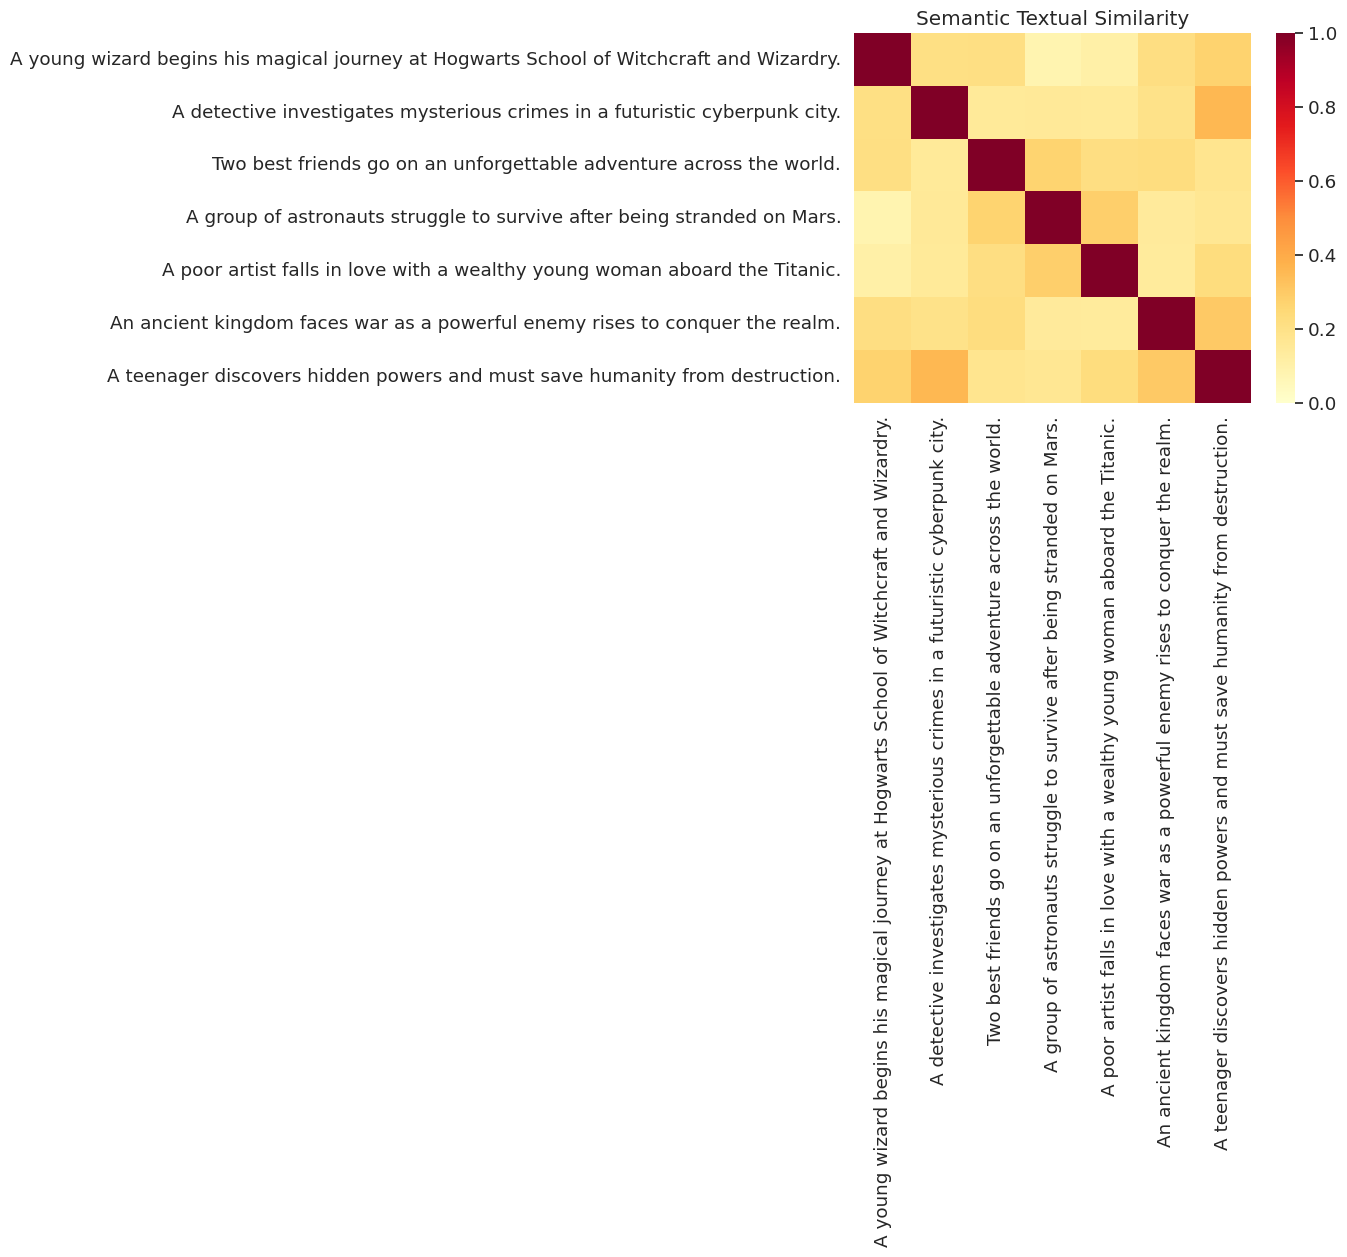

In [ ]:
messages = [
    "A young wizard begins his magical journey at Hogwarts School of Witchcraft and Wizardry.",
    "A detective investigates mysterious crimes in a futuristic cyberpunk city.",
    "Two best friends go on an unforgettable adventure across the world.",
    "A group of astronauts struggle to survive after being stranded on Mars.",
    "A poor artist falls in love with a wealthy young woman aboard the Titanic.",
    "An ancient kingdom faces war as a powerful enemy rises to conquer the realm.",
    "A teenager discovers hidden powers and must save humanity from destruction."
]

run_and_plot(messages)